# 00 — Setup and Bloomberg connection

**Run this notebook first.** It checks that we can talk to Bloomberg and
teaches you how the connection works.

### How the notebooks in this folder fit together

| Notebook | Job |
|---|---|
| `00_setup_and_connection` | check Bloomberg works (this one) |
| `01_pull_market_data` | download all price history and cache it to a CSV |
| `02_detect_incoherence` | find relationship breakdowns/reversions, save them to SQLite |
| `03_surprises_and_sentiment` | score economic data surprises + headline tone |
| `04_dashboard` | show current state of every relationship |

### How Python talks to Bloomberg (the 30-second version)

The Bloomberg Terminal on your PC quietly runs a little server on
`localhost:8194`. The `blpapi` package connects to it, sends a request
("give me SPX Index PX_LAST from 2023 to today") and receives the data.
You must be **logged in to the Terminal** for this to work, and the data
you can pull is exactly what your Terminal licence allows.

To install the API package (one time, in a terminal):
```
pip install blpapi --index-url=https://blpapi.bloomberg.com/repository/releases/python/simple/
```

All the messy request/response code lives in `bbg.py` in this folder, so
the notebooks stay short. Open `bbg.py` and read it — every step is
commented.

In [1]:
import datetime as dt

import matplotlib.pyplot as plt

import bbg  # our helper module (bbg.py in this folder)

if bbg.MOCK_MODE:
    print("blpapi NOT found -> running in MOCK MODE with synthetic data.")
    print("Everything still works; the numbers are just fake.")
else:
    print("blpapi found -> will pull REAL data from your Terminal.")

blpapi NOT found -> running in MOCK MODE with synthetic data.
Everything still works; the numbers are just fake.


### Test pull

`bbg.bdh()` works like the Excel `BDH()` function: give it tickers, a
field, and a date range, and it returns a table (rows = dates,
columns = tickers).

In [2]:
end = dt.date.today()
start = end - dt.timedelta(days=365)

test = bbg.bdh(["SPX Index", "VIX Index"], "PX_LAST", start, end)
print(test.tail())

              SPX Index  VIX Index
2026-07-07  4100.386518  18.779553
2026-07-08  4058.255779  18.688437
2026-07-09  4051.786046  19.247130
2026-07-10  3994.462974  20.798891
2026-07-13  4020.850670  21.059114


If you see numbers above (real or mock), the plumbing works.
Quick sanity plot — SPX and VIX should visibly move opposite to each other
most of the time. That "opposite" behaviour is exactly the kind of
relationship notebook 02 monitors.

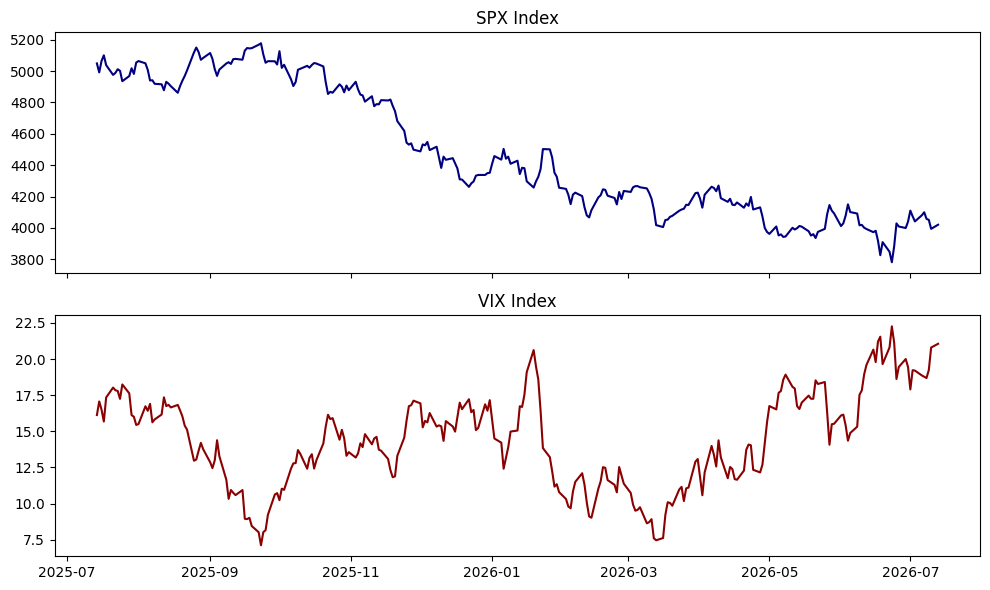

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(test.index, test["SPX Index"], color="navy")
axes[0].set_title("SPX Index")
axes[1].plot(test.index, test["VIX Index"], color="darkred")
axes[1].set_title("VIX Index")
plt.tight_layout()
plt.show()